In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
df = pd.read_csv('/content/datos_tratados.csv')
df.sample(5)

,ID cliente,Desafiliado,Genero,Señor mayor,Pareja,Dependientes,Meses Contrato,Servicio Telefonico,Lineas multiples,Servicio Internet,...,Protección Dispositivo,Soporte Tecnico,Suscripcion TV,Stream Peliculas,Contrato,Factura online,Forma Pago,Total mes,Total,Total dia
4979,6813-GZQCG,False,Female,False,True,True,45,True,True,No,...,True,True,True,True,Two year,True,Credit card (automatic),24.65,1171.30,0.821667
5583,7632-MNYOY,True,Male,True,False,False,66,False,True,Fiber optic,...,True,True,True,True,One year,False,Credit card (automatic),110.90,7432.05,3.696667
5156,7032-LMBHI,False,Female,False,False,False,37,False,True,DSL,...,False,False,True,False,One year,False,Bank transfer (automatic),64.65,2347.85,2.155000
3581,4933-BSAIP,False,Female,False,True,False,40,False,False,No,...,True,True,True,True,Two year,False,Mailed check,19.10,780.10,0.636667
5186,7078-NVFAM,False,Female,False,True,True,32,True,True,DSL,...,False,False,False,False,Month-to-month,True,Electronic check,35.15,1051.05,1.171667


In [3]:
df = df.drop(columns= ['ID cliente','Lineas multiples','Total dia'], axis=1)
df.head(5)

,Desafiliado,Genero,Señor mayor,Pareja,Dependientes,Meses Contrato,Servicio Telefonico,Servicio Internet,Seguridad Online,Suscripcion Respaldo,Protección Dispositivo,Soporte Tecnico,Suscripcion TV,Stream Peliculas,Contrato,Factura online,Forma Pago,Total mes,Total
0,False,Female,False,True,True,9,True,DSL,False,True,False,True,True,False,One year,True,Mailed check,65.6,593.30
1,False,Male,False,False,False,9,False,DSL,False,False,False,False,False,True,Month-to-month,False,Mailed check,59.9,542.40
2,True,Male,False,False,False,4,False,Fiber optic,False,False,True,False,False,False,Month-to-month,True,Electronic check,73.9,280.85
3,True,Male,True,True,False,13,False,Fiber optic,False,True,True,False,True,True,Month-to-month,True,Electronic check,98.0,1237.85
4,True,Female,True,True,False,3,False,Fiber optic,False,False,False,True,True,False,Month-to-month,True,Mailed check,83.9,267.40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Desafiliado             7267 non-null   bool   
 1   Genero                  7267 non-null   object 
 2   Señor mayor             7267 non-null   bool   
 3   Pareja                  7267 non-null   bool   
 4   Dependientes            7267 non-null   bool   
 5   Meses Contrato          7267 non-null   int64  
 6   Servicio Telefonico     7267 non-null   bool   
 7   Servicio Internet       7267 non-null   object 
 8   Seguridad Online        7267 non-null   bool   
 9   Suscripcion Respaldo    7267 non-null   bool   
 10  Protección Dispositivo  7267 non-null   bool   
 11  Soporte Tecnico         7267 non-null   bool   
 12  Suscripcion TV          7267 non-null   bool   
 13  Stream Peliculas        7267 non-null   bool   
 14  Contrato                7267 non-null   

In [5]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [6]:
X = df.drop('Desafiliado',axis=1)
y= df['Desafiliado']

In [7]:
columnas = X.columns

In [8]:
X.columns

Index(['Genero', 'Señor mayor', 'Pareja', 'Dependientes', 'Meses Contrato',
       'Servicio Telefonico', 'Servicio Internet', 'Seguridad Online',
       'Suscripcion Respaldo', 'Protección Dispositivo', 'Soporte Tecnico',
       'Suscripcion TV', 'Stream Peliculas', 'Contrato', 'Factura online',
       'Forma Pago', 'Total mes', 'Total'],
      dtype='object')

In [9]:
one_hot = make_column_transformer((OneHotEncoder(drop='if_binary'),
                                  ['Genero', 'Señor mayor', 'Pareja', 'Dependientes',
                                    'Servicio Telefonico', 'Servicio Internet',
                                    'Seguridad Online', 'Suscripcion Respaldo', 'Protección Dispositivo',
                                    'Soporte Tecnico', 'Suscripcion TV', 'Stream Peliculas', 'Contrato',
                                    'Factura online', 'Forma Pago']),
                                  remainder= 'passthrough',
                                  sparse_threshold=0,
                                  force_int_remainder_cols=False)

In [10]:
X = one_hot.fit_transform(X)

In [11]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__Genero_Male', 'onehotencoder__Señor mayor_True',
       'onehotencoder__Pareja_True', 'onehotencoder__Dependientes_True',
       'onehotencoder__Servicio Telefonico_True',
       'onehotencoder__Servicio Internet_DSL',
       'onehotencoder__Servicio Internet_Fiber optic',
       'onehotencoder__Servicio Internet_No',
       'onehotencoder__Seguridad Online_True',
       'onehotencoder__Suscripcion Respaldo_True',
       'onehotencoder__Protección Dispositivo_True',
       'onehotencoder__Soporte Tecnico_True',
       'onehotencoder__Suscripcion TV_True',
       'onehotencoder__Stream Peliculas_True',
       'onehotencoder__Contrato_Month-to-month',
       'onehotencoder__Contrato_One year',
       'onehotencoder__Contrato_Two year',
       'onehotencoder__Factura online_True',
       'onehotencoder__Forma Pago_Bank transfer (automatic)',
       'onehotencoder__Forma Pago_Credit card (automatic)',
       'onehotencoder__Forma Pago_Electronic check',
       'oneho

In [12]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y

array([0, 0, 1, ..., 0, 0, 0])

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42, stratify=y)

In [15]:
df['Desafiliado'].value_counts()

,count
Desafiliado,
False,5398
True,1869


## <font color='dark'>Balanceo de los datos</h1>

In [16]:
from imblearn.over_sampling import SMOTE

In [17]:
oversampling = SMOTE(random_state=42)
X_train, y_train = oversampling.fit_resample(X_train, y_train)

In [18]:
pd.Series(y_train).value_counts(normalize=True)

,proportion
0,0.5
1,0.5


In [19]:
df.corr(numeric_only=True)

,Desafiliado,Señor mayor,Pareja,Dependientes,Meses Contrato,Servicio Telefonico,Seguridad Online,Suscripcion Respaldo,Protección Dispositivo,Soporte Tecnico,Suscripcion TV,Stream Peliculas,Factura online,Total mes,Total
Desafiliado,1.000000,0.146733,-0.148546,-0.161384,-0.344079,-0.161384,-0.335656,-0.263111,-0.246919,-0.330446,-0.126795,-0.128721,0.186666,0.189866,-0.193345
Señor mayor,0.146733,1.000000,0.022970,-0.212952,0.018187,-0.212952,-0.185060,-0.086008,-0.094148,-0.204636,-0.050994,-0.035229,0.157734,0.220388,0.104076
Pareja,-0.148546,0.022970,1.000000,0.448900,0.377551,0.448900,0.128129,0.133995,0.146857,0.105785,0.124279,0.115691,-0.011201,0.097122,0.315409
Dependientes,-0.161384,-0.212952,0.448900,1.000000,0.159892,1.000000,0.193274,0.141006,0.132415,0.174189,0.104966,0.080066,-0.111752,-0.115832,0.061474
Meses Contrato,-0.344079,0.018187,0.377551,0.159892,1.000000,0.159892,0.265199,0.315280,0.315190,0.261679,0.247669,0.254616,0.007949,0.247982,0.825407
Servicio Telefonico,-0.161384,-0.212952,0.448900,1.000000,0.159892,1.000000,0.193274,0.141006,0.132415,0.174189,0.104966,0.080066,-0.111752,-0.115832,0.061474
Seguridad Online,-0.335656,-0.185060,0.128129,0.193274,0.265199,0.193274,1.000000,0.381203,0.373018,0.472094,0.259242,0.268036,-0.269282,-0.360662,0.063632
Suscripcion Respaldo,-0.263111,-0.086008,0.133995,0.141006,0.315280,0.141006,0.381203,1.000000,0.364911,0.384219,0.317781,0.309411,-0.144176,-0.210850,0.178647
Protección Dispositivo,-0.246919,-0.094148,0.146857,0.132415,0.315190,0.132415,0.373018,0.364911,1.000000,0.419867,0.424563,0.430567,-0.169107,-0.172441,0.189253
Soporte Tecnico,-0.330446,-0.204636,0.105785,0.174189,0.261679,0.174189,0.472094,0.384219,0.419867,1.000000,0.347728,0.347036,-0.233680,-0.323291,0.081595


## **Análisis Dirigido**

In [20]:
px.box(df, x='Meses Contrato', color='Desafiliado')

In [21]:
px.box(df, x='Total', color='Desafiliado')

# **MODELADO PREDICTIVO**

## Utilizando DecissionTree y RandomForest

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold, cross_validate, StratifiedKFold

# Definir las métricas que queremos calcular
scoring = ['accuracy', 'precision', 'recall', 'f1']

arbol = DecisionTreeClassifier(max_depth = 3, min_samples_leaf=10, random_state=42)
random_forest = RandomForestClassifier(max_depth = 2, n_estimators=100, random_state=42)

kf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 5)

# Evaluar el Árbol de Decisión
resultados_arbol = cross_validate(arbol, X_train, y_train, cv=kf, scoring=scoring)

# Evaluar el Random Forest
resultados_rf = cross_validate(random_forest, X_train, y_train, cv=kf, scoring=scoring)

## Utilizando KNN

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

In [24]:
pipeline_knn = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

resultados_knn = cross_validate(
    pipeline_knn,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

## Evaluación de los modelos

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


def mostrar_metricas(nombre, resultados):
    print(f'Resultados para {nombre}:')
    print(f"- Accuracy:  {resultados['test_accuracy'].mean():.4f}")
    print(f"- Precisión: {resultados['test_precision'].mean():.4f}")
    print(f"- Recall:    {resultados['test_recall'].mean():.4f}")
    print(f"- F1-score:  {resultados['test_f1'].mean():.4f}")
    print('-' * 30)

Resultados para Árbol de Decisión:
- Accuracy:  0.7807
- Precisión: 0.7464
- Recall:    0.8513
- F1-score:  0.7950
------------------------------


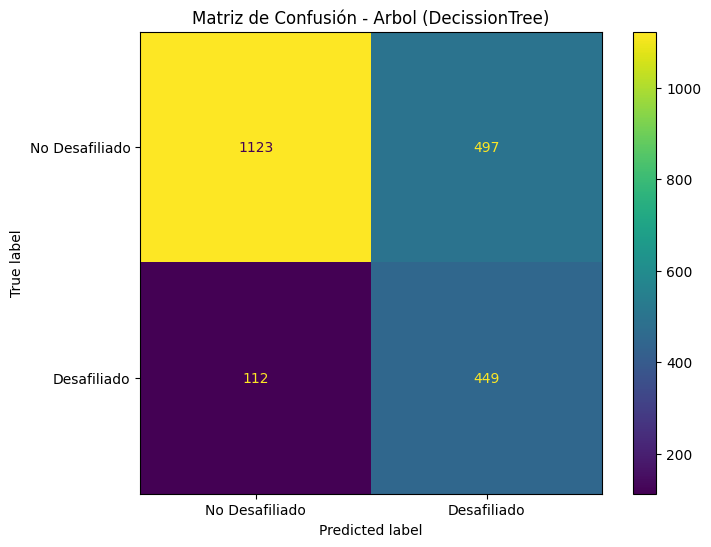

In [26]:
mostrar_metricas('Árbol de Decisión', resultados_arbol)

# Entrenar el modelo Árbol de Decisión en los datos de entrenamiento balanceados
arbol.fit(X_train, y_train)
# Generar predicciones en el conjunto de prueba para la matriz de confusión
y_pred_arbol = arbol.predict(X_test)
cm_arbol = confusion_matrix(y_test, y_pred_arbol)

# Visualización de la matriz de confusión con ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm_arbol, display_labels=['No Desafiliado', 'Desafiliado'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='viridis', ax=ax)
plt.title('Matriz de Confusión - Arbol (DecissionTree)')
plt.show()

Resultados para Random Forest:
- Accuracy:  0.7925
- Precisión: 0.7587
- Recall:    0.8584
- F1-score:  0.8053
------------------------------


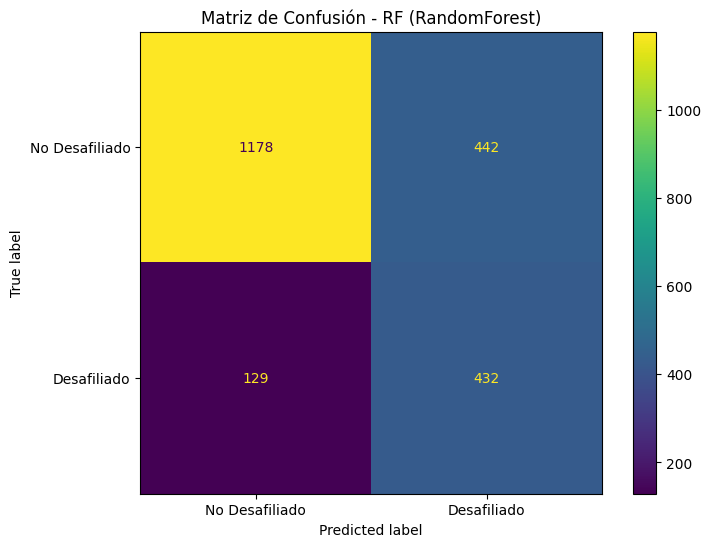

In [27]:
mostrar_metricas('Random Forest', resultados_rf)

# Entrenar el modelo Random Forest en los datos de entrenamiento balanceados
random_forest.fit(X_train, y_train)
# Generar predicciones en el conjunto de prueba para la matriz de confusión
y_pred_rf = random_forest.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Visualización de la matriz de confusión con ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Desafiliado', 'Desafiliado'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='viridis', ax=ax)
plt.title('Matriz de Confusión - RF (RandomForest)')
plt.show()

Resultados para KNN:
- Accuracy:  0.7901
- Precisión: 0.7419
- Recall:    0.8902
- F1-score:  0.8091
------------------------------


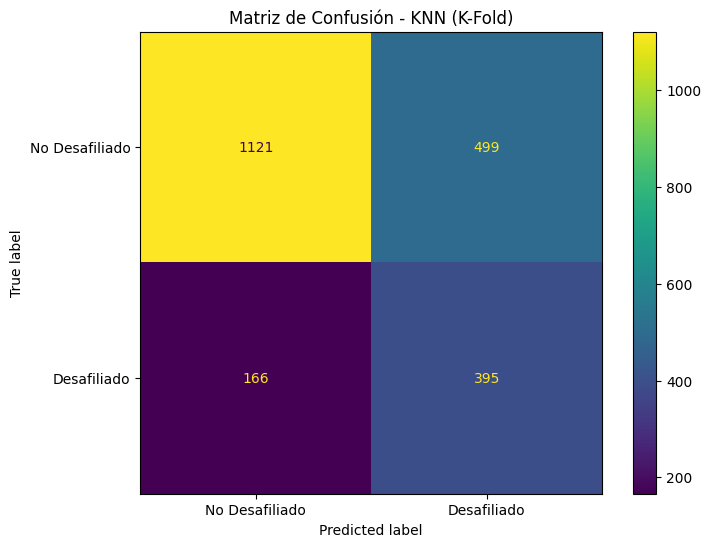

In [28]:
# Mostrar métricas anteriores
mostrar_metricas('KNN', resultados_knn)

# Generar predicciones con validación cruzada para la matriz de confusión
pipeline_knn.fit(X_train, y_train)
y_pred_knn = pipeline_knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred_knn)

# Visualización de la matriz de confusión con ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Desafiliado', 'Desafiliado'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='viridis', ax=ax)
plt.title('Matriz de Confusión - KNN (K-Fold)')
plt.show()

### Probando el modelo

In [29]:
from sklearn.metrics import classification_report

=== Decision Tree ===
Train accuracy: 0.7804393859184754
Test accuracy: 0.7207702888583218
Train F1: 0.7964666912035333
Test F1: 0.5958858659588586
              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1620
           1       0.47      0.80      0.60       561

    accuracy                           0.72      2181
   macro avg       0.69      0.75      0.69      2181
weighted avg       0.80      0.72      0.74      2181



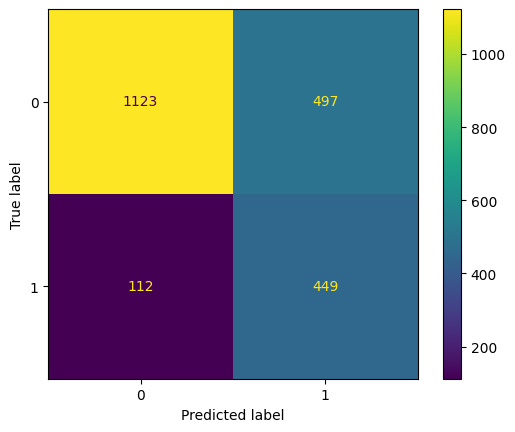

In [30]:
modelo_tree = DecisionTreeClassifier(max_depth = 3, min_samples_leaf=10, random_state=42)

modelo_tree.fit(X_train, y_train)

y_pred_tree = modelo_tree.predict(X_test)
y_pred_tree_train = modelo_tree.predict(X_train)

print("=== Decision Tree ===")
print("Train accuracy:", modelo_tree.score(X_train, y_train))
print("Test accuracy:", modelo_tree.score(X_test, y_test))

print("Train F1:", f1_score(y_train, y_pred_tree_train))
print("Test F1:", f1_score(y_test, y_pred_tree))

print(classification_report(y_test, y_pred_tree))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree);

=== Random Forest ===
Train accuracy: 0.7935415563790366
Test accuracy: 0.7381934892251261
Train F1: 0.8061148396718867
Test F1: 0.6020905923344948
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1620
           1       0.49      0.77      0.60       561

    accuracy                           0.74      2181
   macro avg       0.70      0.75      0.70      2181
weighted avg       0.80      0.74      0.75      2181



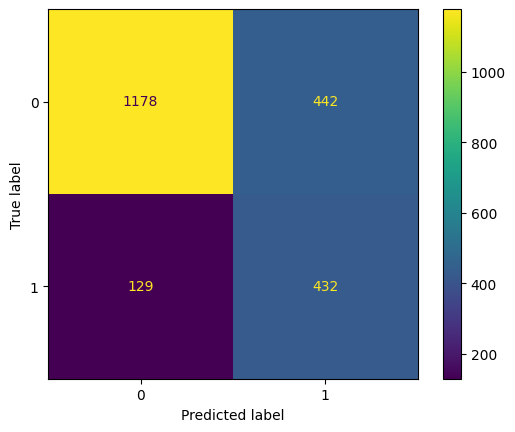

In [31]:
modelo_rf = RandomForestClassifier(max_depth = 2, n_estimators=100, random_state=42)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_pred_rf_train = modelo_rf.predict(X_train)

print("=== Random Forest ===")
print("Train accuracy:", modelo_rf.score(X_train, y_train))
print("Test accuracy:", modelo_rf.score(X_test, y_test))

print("Train F1:", f1_score(y_train, y_pred_rf_train))
print("Test F1:", f1_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf);

=== KNN ===
Train accuracy: 0.6801217575436739
Test accuracy: 0.8266850068775791
Train F1: 0.61604447974583
Test F1: 0.6420454545454546
              precision    recall  f1-score   support

           0       0.87      0.90      0.89      1620
           1       0.68      0.60      0.64       561

    accuracy                           0.83      2181
   macro avg       0.78      0.75      0.76      2181
weighted avg       0.82      0.83      0.82      2181



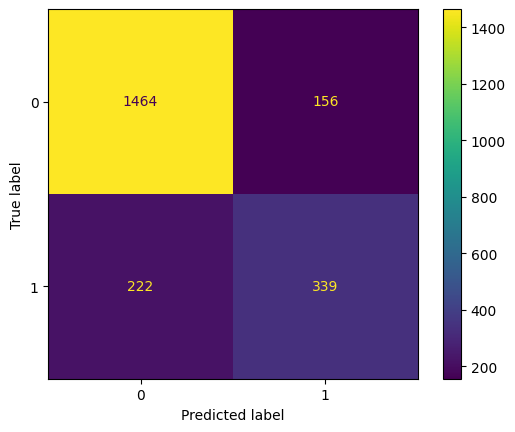

In [32]:
pipeline_knn = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipeline_knn.fit(X_test, y_test)

y_pred_knn = pipeline_knn.predict(X_test)
y_pred_knn_train = pipeline_knn.predict(X_train)

print("=== KNN ===")
print("Train accuracy:", pipeline_knn.score(X_train, y_train))
print("Test accuracy:", pipeline_knn.score(X_test, y_test))

print("Train F1:", f1_score(y_train, y_pred_knn_train))
print("Test F1:", f1_score(y_test, y_pred_knn))

print(classification_report(y_test, y_pred_knn))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn);

# 📊 Análisis comparativo de modelos

Se evaluaron tres modelos de clasificación para predecir churn:

- 🌳 Árbol de Decisión  
- 🌲 Random Forest  
- 🤖 K-Nearest Neighbors (KNN)  

La comparación se realizó utilizando:

- Accuracy
- F1-score (énfasis en clase 1 – churn)
- Recall
- Comparación entre entrenamiento y prueba para detectar sobreajuste

---

## 🌳 Árbol de Decisión

**Entrenamiento**
- Accuracy: 0.780
- F1-score: 0.796

**Prueba**
- Accuracy: 0.721
- F1-score: 0.596
- Recall clase churn: 0.80
- Precision clase churn: 0.47

🔎 Análisis:

- Se observa una diferencia notable entre Train F1 (0.796) y Test F1 (0.596).
- Esto indica presencia de sobreajuste.
- El modelo detecta bien a los clientes churn (recall alto: 0.80), pero con baja precisión (muchos falsos positivos).

📌 Conclusión:  
Modelo interpretable, pero con alta varianza y menor capacidad de generalización.

---

## 🌲 Random Forest

**Entrenamiento**
- Accuracy: 0.794
- F1-score: 0.806

**Prueba**
- Accuracy: 0.738
- F1-score: 0.602
- Recall clase churn: 0.77
- Precision clase churn: 0.49

🔎 Análisis:

- Diferencia entre Train F1 (0.806) y Test F1 (0.602) menor que en el Árbol.
- Mejor estabilidad y menor sobreajuste.
- Buen balance entre precision y recall.
- Accuracy superior al Árbol en test.

📌 Conclusión:  
Modelo más robusto y equilibrado. Presenta mejor generalización y estabilidad.

---

## 🤖 K-Nearest Neighbors (KNN)

**Entrenamiento**
- Accuracy: 0.680
- F1-score: 0.616

**Prueba**
- Accuracy: 0.827
- F1-score: 0.642
- Recall clase churn: 0.60
- Precision clase churn: 0.68

🔎 Análisis:

- El rendimiento en test es mayor que en entrenamiento.
- No muestra señales claras de sobreajuste.
- Mayor precisión en clase churn (0.68).
- Menor recall que Árbol y Random Forest (0.60).

📌 Conclusión:  
Modelo más conservador: comete menos falsos positivos, pero detecta menos churn reales.

---

# 🏆 Modelo seleccionado

Si el objetivo del negocio es:

### 🎯 Maximizar detección de clientes en riesgo (priorizar Recall)
El Árbol y Random Forest detectan más churn (≈ 0.77–0.80).

### ⚖ Buscar equilibrio general y estabilidad
Random Forest es el modelo más robusto.

### 🎯 Reducir falsos positivos
KNN ofrece mayor precision en clase churn (0.68).

---

# 📌 Decisión final

El modelo recomendado es Random Forest, debido a:

- Mejor estabilidad entre Train y Test  
- Buen balance entre precision y recall  
- F1 competitivo  
- Menor tendencia al sobreajuste  

---

# 💼 Interpretación de negocio

El modelo prioriza la identificación de clientes en riesgo de cancelación.  
Aunque se generan algunos falsos positivos, desde la perspectiva empresarial es preferible intervenir preventivamente antes que perder clientes reales.

# ANÁLISIS DE LAS IMPORTANCIAS DE LAS VARIABLES

## 1️⃣ ARBOL DE DECISIÓN

In [33]:
modelo_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

modelo_tree.fit(X_train, y_train)

importancias_tree = modelo_tree.feature_importances_

nombres_features = one_hot.get_feature_names_out() # Define nombres_features here

feature_importances_tree = pd.DataFrame({
    'Feature': nombres_features,
    'Importancia (%)': (importancias_tree * 100).round(2)
})

feature_importances_tree = feature_importances_tree.sort_values(
    by='Importancia (%)',
    ascending=False
)

feature_importances_tree.head(10)

,Feature,Importancia (%)
14,onehotencoder__Contrato_Month-to-month,68.16
20,onehotencoder__Forma Pago_Electronic check,25.51
8,onehotencoder__Seguridad Online_True,3.34
6,onehotencoder__Servicio Internet_Fiber optic,2.99
0,onehotencoder__Genero_Male,0.00
4,onehotencoder__Servicio Telefonico_True,0.00
3,onehotencoder__Dependientes_True,0.00
1,onehotencoder__Señor mayor_True,0.00
2,onehotencoder__Pareja_True,0.00
7,onehotencoder__Servicio Internet_No,0.00


## 2️⃣ RANDOM FOREST

In [34]:
# Entrenar modelo
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Importancias
importancias_rf = modelo_rf.feature_importances_

feature_importances_rf = pd.DataFrame({
    'Feature': nombres_features,
    'Importance (%)': (importancias_rf * 100).round(2)
}).sort_values(by='Importance (%)', ascending=False)

feature_importances_rf

,Feature,Importance (%)
24,remainder__Total,11.82
14,onehotencoder__Contrato_Month-to-month,10.22
22,remainder__Meses Contrato,9.83
23,remainder__Total mes,9.82
11,onehotencoder__Soporte Tecnico_True,7.35
20,onehotencoder__Forma Pago_Electronic check,7.29
8,onehotencoder__Seguridad Online_True,6.44
9,onehotencoder__Suscripcion Respaldo_True,5.01
17,onehotencoder__Factura online_True,3.72
16,onehotencoder__Contrato_Two year,2.88


## 3️⃣ KNN — Importancia de Variables

In [35]:
from sklearn.inspection import permutation_importance

# Entrenar modelo KNN
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train, y_train)

# Obtener nombres de las variables desde el OneHotEncoder
nombres_features = one_hot.get_feature_names_out()

# Calcular permutation importance usando el conjunto de prueba
resultado_knn = permutation_importance(
    modelo_knn,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

# Crear DataFrame con importancias
importancia_knn = pd.DataFrame({
    'Feature': nombres_features,
    'Importance': resultado_knn.importances_mean
}).sort_values(by='Importance', ascending=False)

importancia_knn

,Feature,Importance
24,remainder__Total,0.093764
23,remainder__Total mes,0.081522
22,remainder__Meses Contrato,0.019303
17,onehotencoder__Factura online_True,0.001880
21,onehotencoder__Forma Pago_Mailed check,0.001100
14,onehotencoder__Contrato_Month-to-month,0.000825
5,onehotencoder__Servicio Internet_DSL,0.000779
1,onehotencoder__Señor mayor_True,0.000642
12,onehotencoder__Suscripcion TV_True,0.000596
15,onehotencoder__Contrato_One year,0.000504


# 📊 Análisis Comparativo Final – Modelos de Churn
Telecom X – Machine Learning

------------------------------------------------------------
1️⃣ Árbol de Decisión  

Variables más importantes:

- Contrato_Month-to-month → 68.16%  
- Forma Pago_Electronic check → 25.51%  
- Seguridad Online_True → 3.34%  
- Servicio Internet_Fiber optic → 2.99%  

Interpretación:

El Árbol de Decisión muestra una dependencia extremadamente fuerte
del tipo de contrato mensual, que concentra más del 68% de la importancia total.

Sin embargo, a diferencia del análisis anterior, ahora el segundo factor
más relevante es el método de pago Electronic Check (25.51%),
lo que indica que la forma de pago tiene un impacto mucho mayor
del que se observaba previamente.

La Seguridad Online y la Fibra Óptica tienen un peso menor,
pero siguen contribuyendo al riesgo de cancelación.

Conclusión:
El churn está altamente concentrado en clientes con contrato mensual
y que pagan mediante Electronic Check.
El modelo es muy interpretable, pero depende fuertemente
de pocas variables dominantes.

------------------------------------------------------------  
2️⃣ Random Forest  

Variables más importantes:

- Total → 11.82%  
- Contrato_Month-to-month → 10.22%  
- Meses Contrato → 9.83%  
- Total mes → 9.82%  
- Soporte Tecnico_True → 7.35%  
- Forma Pago_Electronic check → 7.29%  
- Seguridad Online_True → 6.44%  

Interpretación:

Random Forest presenta una distribución mucho más equilibrada
de la importancia entre variables.

Aquí no domina una sola variable,
sino una combinación de:

- Variables financieras (Total y Total mes)
- Antigüedad del cliente (Meses Contrato)
- Tipo de contrato
- Servicios adicionales como Soporte Técnico
- Forma de pago

Esto confirma que el churn no depende únicamente del contrato,
sino de una combinación entre compromiso,
antigüedad e inversión económica.

Conclusión:
Random Forest captura mejor la complejidad del problema,
distribuyendo el peso entre múltiples factores.
Es un modelo más robusto y realista para producción.

------------------------------------------------------------  
3️⃣ KNN (Permutation Importance)

Variables más influyentes:

- Total → 0.0938  
- Total mes → 0.0815  
- Meses Contrato → 0.0193  
- Factura online_True → 0.0019  
- Forma Pago_Mailed check → 0.0011  
- Contrato_Month-to-month → 0.0008  

Interpretación:

KNN muestra que las variables financieras
son claramente las más determinantes
en la similitud entre clientes que cancelan.

El Total acumulado y el gasto mensual
son los principales diferenciadores
entre clientes que churn y los que permanecen.

Las variables contractuales aparecen,
pero con impacto considerablemente menor
en comparación con los modelos basados en árboles.

Conclusión:
El churn responde principalmente a patrones financieros
cuando se analiza desde un modelo basado en distancia.
KNN prioriza similitud económica más que estructura contractual.

------------------------------------------------------------  

📌 Comparación Estratégica Final  

Árbol de Decisión:
- Altamente interpretable  
- Fuerte dependencia del contrato mensual  
- Gran concentración de importancia en pocas variables  

Random Forest:
- Importancias balanceadas  
- Integra variables financieras, contractuales y de servicio  
- Mejor representación de la complejidad del churn  

KNN:
- Basado en similitud  
- Enfatiza principalmente variables financieras  
- Menor capacidad explicativa directa  

------------------------------------------------------------  

🏆 Modelo Recomendado: Random Forest  

Se selecciona Random Forest por:

- Mejor distribución de importancia  
- Captura de interacciones complejas  
- Menor dependencia de una sola variable  
- Mayor robustez para escenarios reales  

Desde la perspectiva de negocio,
permite diseñar estrategias más integrales
y no solo enfocadas en el tipo de contrato.

# CONCLUSION

# 📊 INFORME TÉCNICO FINAL  
Telecom X – Predicción de Cancelación (Churn)

------------------------------------------------------------
1️⃣ Objetivo del Proyecto

Desarrollar modelos predictivos capaces de anticipar qué clientes
presentan mayor probabilidad de cancelar sus servicios, con el fin
de diseñar estrategias de retención efectivas basadas en datos.

------------------------------------------------------------
2️⃣ Modelos Implementados

Se entrenaron tres modelos de clasificación:

- Árbol de Decisión
- Random Forest
- K-Nearest Neighbors (KNN)

Se utilizó codificación OneHotEncoder,
escalado cuando fue necesario (KNN)
y balanceo de clases para mejorar la capacidad predictiva.

------------------------------------------------------------
3️⃣ Rendimiento de los Modelos

Árbol de Decisión:
Train Accuracy: 0.780
Test Accuracy: 0.721
F1 Test: 0.596
Recall Churn (Test): 0.80

Random Forest:
Train Accuracy: 0.794
Test Accuracy: 0.738
F1 Test: 0.602
Recall Churn (Test): 0.77

KNN:
Train Accuracy: 0.680
Test Accuracy: 0.827
F1 Test: 0.642
Recall Churn (Test): 0.60

------------------------------------------------------------
Análisis de Overfitting / Generalización

- Árbol de Decisión muestra diferencia entre train y test,
  indicando tendencia a sobreajuste.

- Random Forest presenta mejor estabilidad entre entrenamiento
  y prueba, mostrando mejor capacidad de generalización.

- KNN no presenta sobreajuste clásico,
  pero prioriza accuracy general sobre recall de churn,
  detectando menos casos positivos.

El modelo más robusto y balanceado fue Random Forest.

------------------------------------------------------------
4️⃣ Variables Más Relevantes

🔹 Árbol de Decisión:

- Contrato_Month-to-month → 68.16%
- Forma Pago_Electronic check → 25.51%
- Seguridad Online_True → 3.34%
- Servicio Internet_Fiber optic → 2.99%

Interpretación:

El churn está fuertemente concentrado en clientes
con contrato mensual.

Además, el uso de Electronic Check
se consolida como el segundo factor más influyente,
lo que sugiere un perfil de mayor riesgo
asociado a métodos de pago no automáticos.

------------------------------------------------------------
🔹 Random Forest:

Variables principales:

- Total → 11.82%
- Contrato_Month-to-month → 10.22%
- Meses Contrato → 9.83%
- Total mes → 9.82%
- Soporte Tecnico_True → 7.35%
- Forma Pago_Electronic check → 7.29%
- Seguridad Online_True → 6.44%

Interpretación:

La cancelación depende de una combinación entre:

- Nivel de gasto
- Antigüedad
- Tipo de contrato
- Servicios adicionales
- Forma de pago

Random Forest distribuye la importancia
entre múltiples variables,
capturando mejor la complejidad del churn.

------------------------------------------------------------
🔹 KNN (Permutation Importance):

Variables asociadas al patrón de similitud:

- Total → 0.0938
- Total mes → 0.0815
- Meses Contrato → 0.0193
- Factura online_True → 0.0019
- Forma Pago_Mailed check → 0.0011
- Contrato_Month-to-month → 0.0008

Interpretación:

KNN enfatiza principalmente variables financieras.
El gasto acumulado y mensual son los principales
diferenciadores entre clientes que cancelan y los que permanecen.

------------------------------------------------------------
5️⃣ Factores Consistentes en los Tres Modelos

Los factores que más influyen en la cancelación son:

1. Tipo de contrato (Month-to-month = mayor riesgo)
2. Nivel de gasto (Total y Total mes)
3. Antigüedad del cliente
4. Servicios adicionales (Seguridad Online / Soporte Técnico)
5. Método de pago (especialmente Electronic Check)

------------------------------------------------------------
6️⃣ Perfil del Cliente con Mayor Riesgo de Churn

- Cliente con contrato mensual
- Antigüedad baja o intermedia
- Menor inversión acumulada
- Uso de Electronic Check
- Sin servicios adicionales activos

------------------------------------------------------------
7️⃣ Estrategias de Retención Recomendadas

1. Incentivar migración a contratos de mayor plazo
   mediante descuentos o beneficios exclusivos.

2. Promover pago automático
   reduciendo fricción y morosidad.

3. Ofrecer bundles con Seguridad Online
   y Soporte Técnico incluidos.

4. Diseñar campañas específicas para clientes
   con bajo gasto acumulado en los primeros meses.

5. Implementar Random Forest en producción
   como modelo base para scoring de churn.

------------------------------------------------------------
8️⃣ Conclusión Final

El churn en Telecom X no depende de un único factor,
sino de una combinación entre:

- Compromiso contractual
- Nivel de inversión
- Antigüedad
- Servicios adicionales
- Forma de pago

Random Forest demostró mayor robustez y equilibrio,
capturando múltiples dimensiones del comportamiento del cliente.

La implementación de este modelo permitiría
anticipar la cancelación y aplicar estrategias
preventivas focalizadas,
optimizando recursos de retención.